In [89]:
import sys
import os

sys.path.append(os.path.abspath(".."))  # or "." depending on location

In [ ]:
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier
from sklearn.model_selection import cross_validate
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier

import pandas as pd
import matplotlib.pyplot as plt


from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder, StandardScaler

from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import accuracy_score, f1_score, classification_report


from src.pipeline import build_pipeline

In [91]:
df = pd.read_csv("https://raw.githubusercontent.com/ananyaghorpade29/titanic/refs/heads/main/data/Titanic-Dataset.csv")
df.head()

x= df.drop(["Survived", "Name", "Ticket", "Cabin", "PassengerId"], axis=1)
y= df["Survived"]

X_train, X_test, y_train, y_test = train_test_split(x, y, test_size=0.2, random_state=42)
print("Train size:", X_train.shape, "| Test size:", X_test.shape)

categorical_cols = ["Sex", "Embarked"]
numerical_cols = ["Age", "Fare", "Pclass", "SibSp", "Parch"]

numeric_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])

categorical_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("onehot", OneHotEncoder(handle_unknown="ignore"))
])

preprocessor = ColumnTransformer([
    ("num", numeric_pipeline, numerical_cols),
    ("cat", categorical_pipeline, categorical_cols),
])

pipelines = {
    "RandomForest":        build_pipeline(RandomForestClassifier(random_state=42)),
    "XGBoost":             build_pipeline(XGBClassifier(eval_metric='logloss', random_state=42)),
    "LightGBM":            build_pipeline(LGBMClassifier(random_state=42, verbose=-1)),
    "LogisticRegression":  build_pipeline(LogisticRegression(max_iter=1000)),
    "DecisionTree":        build_pipeline(DecisionTreeClassifier(random_state=42)),
}
print("Pipelines ready:", list(pipelines.keys()))

baseline_results = []

for name, pipe in pipelines.items():
    pipe.fit(X_train, y_train)
    y_pred = pipe.predict(X_test)
    baseline_results.append({
        "Model": name,
        "Accuracy": round(accuracy_score(y_test, y_pred), 4),
        "F1 Score": round(f1_score(y_test, y_pred), 4)
    })

baseline_df = pd.DataFrame(baseline_results).sort_values("F1 Score", ascending=False)
print("\n Baseline Model Comparison:")
print(baseline_df.to_string(index=False))

Train size: (712, 7) | Test size: (179, 7)
Pipelines ready: ['RandomForest', 'XGBoost', 'LightGBM', 'LogisticRegression', 'DecisionTree']

 Baseline Model Comparison:
             Model  Accuracy  F1 Score
          LightGBM    0.8268    0.7891
      RandomForest    0.8212    0.7746
           XGBoost    0.8101    0.7671
LogisticRegression    0.8101    0.7639
      DecisionTree    0.7933    0.7517


C:\Users\Dell\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


In [92]:
# tuning
best_models = {}

# --- Random Forest ---
param_grid_rf = {
    "model__n_estimators": [100, 200, 300],
    "model__max_depth": [None, 10, 20],
    "model__min_samples_split": [2, 5]
}
grid_rf = GridSearchCV(
    build_pipeline(RandomForestClassifier(random_state=42)),
    param_grid_rf, cv=5, scoring="f1", n_jobs=-1, verbose=1
)
grid_rf.fit(X_train, y_train)
print("✅ RandomForest Best Params:", grid_rf.best_params_)
print("   Best CV F1:", round(grid_rf.best_score_, 4))
best_models["RandomForest (Tuned)"] = grid_rf.best_estimator_

# --- XGBoost ---
param_grid_xgb = {
    "model__learning_rate": [0.01, 0.05, 0.1],
    "model__max_depth": [3, 5, 7],
    "model__n_estimators": [100, 200]
}
grid_xgb = GridSearchCV(
    build_pipeline(XGBClassifier(eval_metric='logloss', random_state=42)),
    param_grid_xgb, cv=5, scoring="f1", n_jobs=-1, verbose=1
)
grid_xgb.fit(X_train, y_train)
print("\n✅ XGBoost Best Params:", grid_xgb.best_params_)
print("   Best CV F1:", round(grid_xgb.best_score_, 4))
best_models["XGBoost (Tuned)"] = grid_xgb.best_estimator_

# --- LightGBM ---
param_grid_lgbm = {
    "model__num_leaves": [20, 31, 50],
    "model__learning_rate": [0.01, 0.05, 0.1],
    "model__n_estimators": [100, 200, 300]
}
grid_lgbm = GridSearchCV(
    build_pipeline(LGBMClassifier(random_state=42, verbose=-1)),
    param_grid_lgbm, cv=5, scoring="f1", n_jobs=-1, verbose=1
)
grid_lgbm.fit(X_train, y_train)
print("\n✅ LightGBM Best Params:", grid_lgbm.best_params_)
print("   Best CV F1:", round(grid_lgbm.best_score_, 4))
best_models["LightGBM (Tuned)"] = grid_lgbm.best_estimator_

Fitting 5 folds for each of 18 candidates, totalling 90 fits
✅ RandomForest Best Params: {'model__max_depth': 10, 'model__min_samples_split': 2, 'model__n_estimators': 300}
   Best CV F1: 0.7504
Fitting 5 folds for each of 18 candidates, totalling 90 fits

✅ XGBoost Best Params: {'model__learning_rate': 0.05, 'model__max_depth': 3, 'model__n_estimators': 200}
   Best CV F1: 0.76
Fitting 5 folds for each of 27 candidates, totalling 135 fits

✅ LightGBM Best Params: {'model__learning_rate': 0.1, 'model__n_estimators': 100, 'model__num_leaves': 20}
   Best CV F1: 0.7569


In [95]:
# Best model = LightGBM tuned
best_model = best_models["LightGBM (Tuned)"]
y_pred_final = best_model.predict(X_test)

print("FINAL MODEL PERFORMANCE (LightGBM Tuned):")
print("Accuracy:", round(accuracy_score(y_test, y_pred_final), 4))
print("F1 Score:", round(f1_score(y_test, y_pred_final), 4))
print("\n Classification Report:")
print(classification_report(y_test, y_pred_final))

FINAL MODEL PERFORMANCE (LightGBM Tuned):
Accuracy: 0.8268
F1 Score: 0.7919

 Classification Report:
              precision    recall  f1-score   support

           0       0.86      0.85      0.85       105
           1       0.79      0.80      0.79        74

    accuracy                           0.83       179
   macro avg       0.82      0.82      0.82       179
weighted avg       0.83      0.83      0.83       179



C:\Users\Dell\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


In [97]:

#Evaluate with 5-Fold CV
scoring = ["accuracy", "f1"]

cv_models = {
    "RandomForest (Tuned)":   best_models["RandomForest (Tuned)"],
    "XGBoost (Tuned)":        best_models["XGBoost (Tuned)"],
    "LightGBM (Tuned)":       best_models["LightGBM (Tuned)"],
    "LogisticRegression":     build_pipeline(LogisticRegression(max_iter=1000)),
    "DecisionTree":           build_pipeline(DecisionTreeClassifier(random_state=42)),
}

cv_results = []
for name, model in cv_models.items():
    scores = cross_validate(model, X_train, y_train, cv=5, scoring=scoring)
    cv_results.append({
        "Model":    name,
        "Accuracy": round(scores["test_accuracy"].mean(), 4),
        "F1 Score": round(scores["test_f1"].mean(), 4)
    })

results_df = pd.DataFrame(cv_results).sort_values("F1 Score", ascending=False).reset_index(drop=True)
print("5-Fold CV Results (all 5 models):")
print(results_df.to_string(index=False))


C:\Users\Dell\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
C:\Users\Dell\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
C:\Users\Dell\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
C:\Users\Dell\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-package

5-Fold CV Results (all 5 models):
               Model  Accuracy  F1 Score
     XGBoost (Tuned)    0.8343    0.7600
    LightGBM (Tuned)    0.8258    0.7569
RandomForest (Tuned)    0.8244    0.7504
  LogisticRegression    0.7907    0.7063
        DecisionTree    0.7486    0.6743


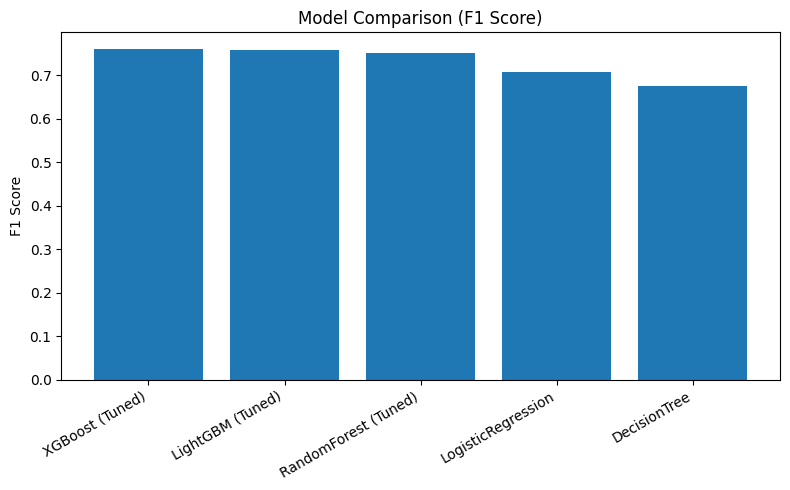

In [101]:
#visualize
# visualize
plt.figure(figsize=(8, 5))
plt.bar(results_df["Model"], results_df["F1 Score"])

plt.xticks(rotation=30, ha="right")
plt.title("Model Comparison (F1 Score)")
plt.ylabel("F1 Score")
plt.tight_layout()
plt.show()